In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM,Dropout

from sklearn.metrics import mean_squared_error

In [ ]:
ticket=input("Enter the stock ticker symbol : ")
data=yf.download(ticket,period="10y",interval="1d")
data.to_csv(f"{ticket}.csv")

Enter the stock ticker symbol : AAPL


/tmp/ipykernel_521/2552183601.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(ticket,period="10y",interval="1d")
[*********************100%***********************]  1 of 1 completed


In [ ]:
df=pd.read_csv(f'{ticket}.csv')
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2016-08-01,24.142253875732422,24.16501850072012,23.768908468079626,23.768908468079626,152671600
3,2016-08-02,23.78483772277832,24.146799855832086,23.675565119560158,24.14224762674467,135266400
4,2016-08-03,24.08305549621582,24.09443693605807,23.850851892023883,23.85995808599503,120810400


In [ ]:
df.tail()

,Price,Close,High,Low,Open,Volume
2510,2026-07-24,333.0199890136719,334.3699951171875,321.6199951171875,321.7900085449219,47489400
2511,2026-07-27,336.9100036621094,339.57000732421875,334.0199890136719,334.5400085449219,49604300
2512,2026-07-28,340.0799865722656,342.8900146484375,335.6000061035156,340.0299987792969,51859000
2513,2026-07-29,338.19000244140625,344.57000732421875,337.3500061035156,339.7300109863281,56090800
2514,2026-07-30,333.42999267578125,334.75,329.5899963378906,333.1000061035156,73355100


In [ ]:
df.shape

(2515, 6)

In [ ]:
df=df.iloc[2:,0:2]

In [ ]:
df.head()

,Price,Close
2,2016-08-01,24.142253875732422
3,2016-08-02,23.78483772277832
4,2016-08-03,24.08305549621582
5,2016-08-04,24.231828689575195
6,2016-08-05,24.60033416748047


In [ ]:
df.shape

(2513, 2)

In [ ]:
df=df.rename(columns={"Price":"Date"})

In [ ]:
df.head()

,Date,Close
2,2016-08-01,24.142253875732422
3,2016-08-02,23.78483772277832
4,2016-08-03,24.08305549621582
5,2016-08-04,24.231828689575195
6,2016-08-05,24.60033416748047


In [ ]:
df["Date"]=pd.to_datetime(df["Date"])
df.set_index("Date",inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2513 entries, 2016-08-01 to 2026-07-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Close   2513 non-null   object
dtypes: object(1)
memory usage: 39.3+ KB


In [ ]:
df.head()

,Close
Date,
2016-08-01,24.142253875732422
2016-08-02,23.78483772277832
2016-08-03,24.08305549621582
2016-08-04,24.231828689575195
2016-08-05,24.60033416748047


In [ ]:
df.to_csv(f"{ticket}_v2.csv")

In [ ]:
df["Close"]=pd.to_numeric(df["Close"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2513 entries, 2016-08-01 to 2026-07-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2513 non-null   float64
dtypes: float64(1)
memory usage: 39.3 KB


In [ ]:
df.head()

,Close
Date,
2016-08-01,24.142254
2016-08-02,23.784838
2016-08-03,24.083055
2016-08-04,24.231829
2016-08-05,24.600334


In [ ]:
df.shape

(2513, 1)

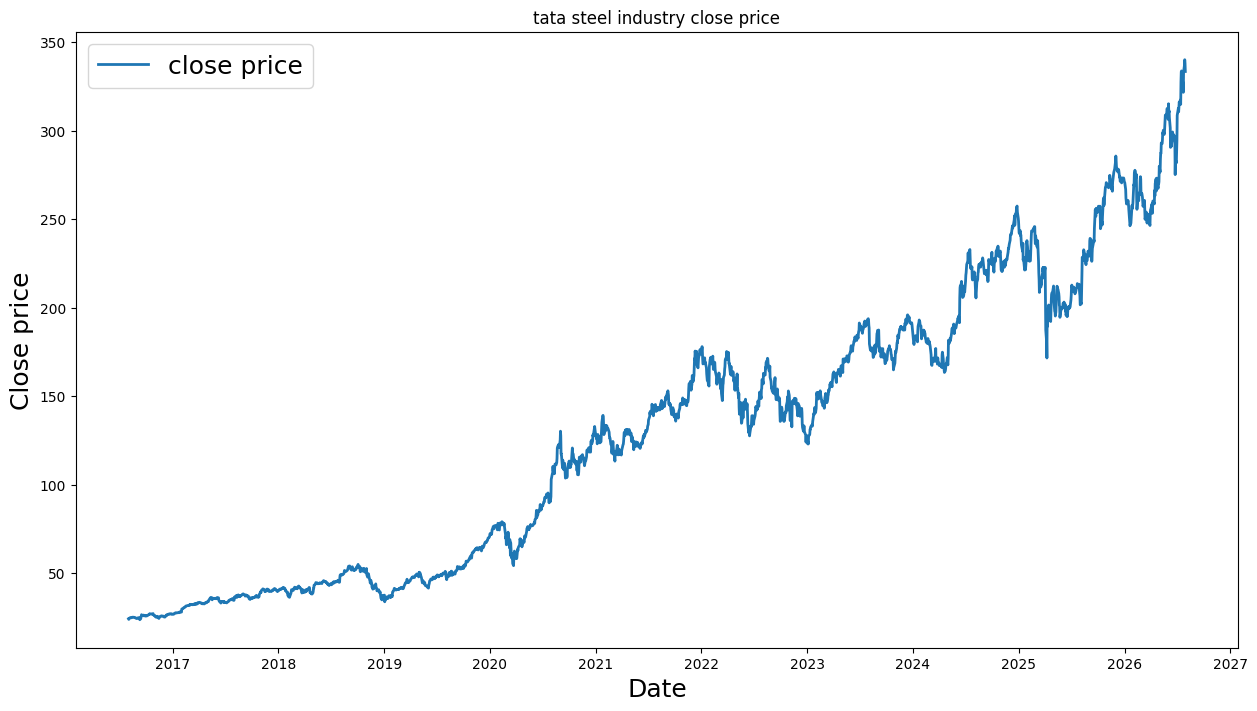

In [ ]:
plt.figure(figsize=(15,8))
plt.title("tata steel industry close price")
plt.plot(df["Close"],label="close price",linewidth=2)
plt.xlabel("Date",fontsize=18)
plt.ylabel("Close price",fontsize=18)
plt.legend(fontsize=18)



In [ ]:
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(df)

In [ ]:
scaled_data

array([[1.69859490e-03],
       [5.69229805e-04],
       [1.51153961e-03],
       ...,
       [1.00000000e+00],
       [9.94028020e-01],
       [9.78987321e-01]])

In [ ]:
def create_sequence(data,time_steps=60):
  X=[]
  Y=[]
  for i in range(time_steps,len(data)):
    X.append(data[i-time_steps:i,0])
    Y.append(data[i,0])
  return np.array(X),np.array(Y)

TIME_STEPS=60
X,y=create_sequence(scaled_data,TIME_STEPS)

X=X.reshape(X.shape[0],X.shape[1],1)



In [ ]:
train_size=int(len(X)*0.8)

X_train,X_test=X[:train_size],X[train_size:]
y_train,y_test=y[:train_size],y[train_size:]

In [ ]:
X_train.shape ,y_train.shape

((1962, 60, 1), (1962,))

In [ ]:
model=Sequential()

model.add(LSTM(units=50,return_sequences=True,input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50,return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer="adam",loss="mean_squared_error",metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(X_train,y_train,batch_size=32,epochs=30,validation_data=(X_test,y_test))

Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.0000e+00 - loss: 0.0073 - val_accuracy: 0.0020 - val_loss: 0.0021
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.0000e+00 - loss: 0.0011 - val_accuracy: 0.0020 - val_loss: 0.0011
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.0000e+00 - loss: 9.8000e-04 - val_accuracy: 0.0020 - val_loss: 8.6257e-04
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.0000e+00 - loss: 9.4131e-04 - val_accuracy: 0.0020 - val_loss: 8.3132e-04
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.0000e+00 - loss: 8.9001e-04 - val_accuracy: 0.0020 - val_loss: 0.0016
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.0000e+00 - loss: 7.8405e-04 - val_accuracy: 0.0020 - val_loss: 8.8210e-04
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.0000e+00 - loss: 7.8262e-04 - val_accuracy: 0.0020 - val_loss: 0.0029
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step 

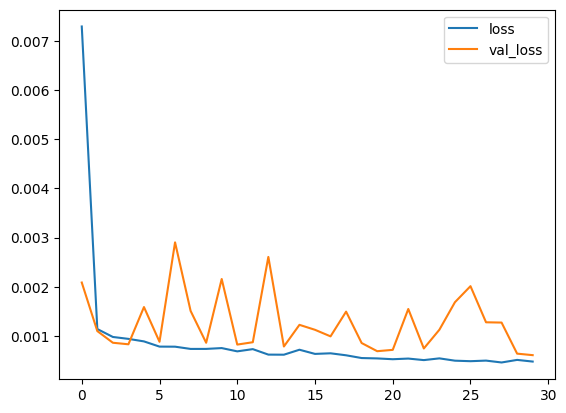

In [ ]:
plt.plot(history.history["loss"],label="loss")
plt.plot(history.history["val_loss"],label="val_loss")
plt.legend()

In [ ]:
predictions=model.predict(X_test)
predictions=scaler.inverse_transform(predictions.reshape(-1,1))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


In [ ]:
y_test_actual=scaler.inverse_transform(y_test.reshape(-1,1))

In [ ]:
rmse=np.sqrt(mean_squared_error(y_test_actual,predictions))

In [ ]:
rmse

np.float64(7.819213073213403)

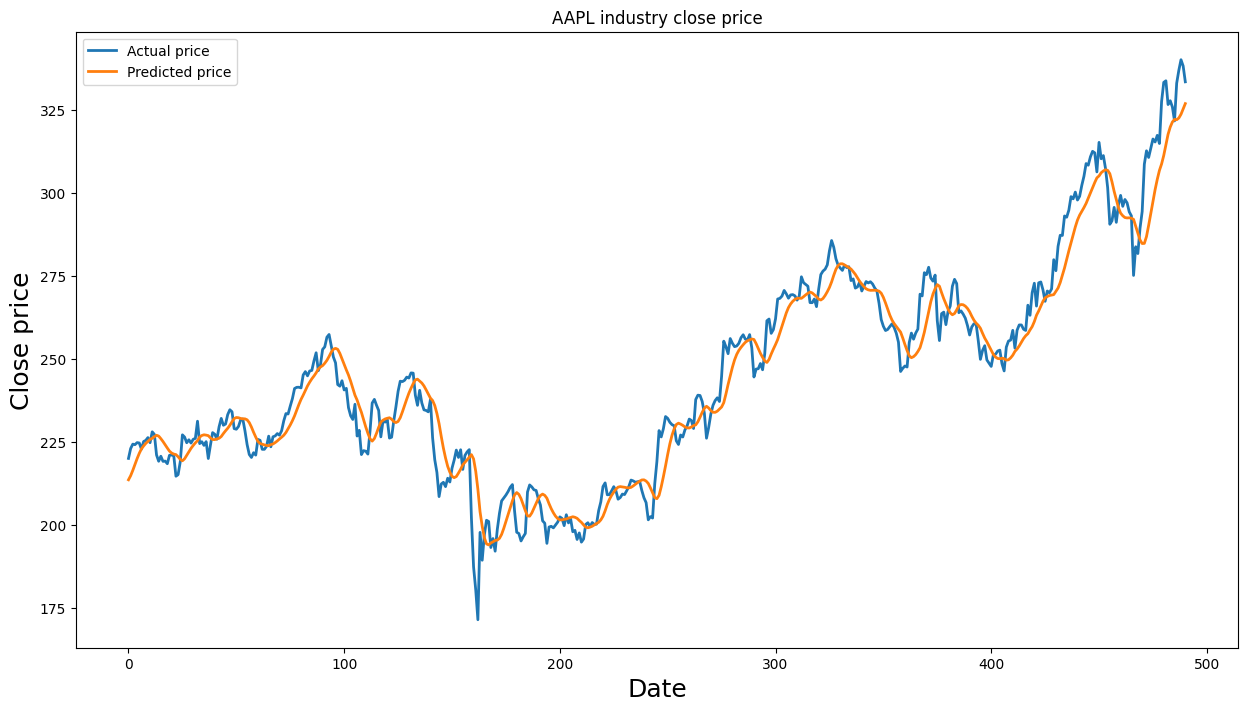

In [ ]:
plt.figure(figsize=(15,8))
plt.title(f"{ticket} industry close price")
plt.plot(y_test_actual,label="Actual price",linewidth=2)
plt.plot(predictions,label="Predicted price",linewidth=2)
plt.xlabel("Date",fontsize=18)
plt.ylabel("Close price",fontsize=18)
plt.legend()

In [ ]:
last_60_days=scaled_data[-60:]
last_60_days=last_60_days.reshape((1,TIME_STEPS,1))
next_day_price=model.predict(last_60_days)
next_day_price=scaler.inverse_transform(next_day_price)
print("next_day_price:",next_day_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
next_day_price: [[327.77628]]


In [ ]:
#model.save('lstm_model.h5')

In [ ]:
# import pickle
# with open('scaler.pkl', 'wb') as f:
#        pickle.dump(scaler, f)